In [1]:
!pip install langchain langgraph langchain-community chromadb sqlite-utils

  Using cached click-8.3.3-py3-none-any.whl.metadata (2.6 kB)
  Using cached tabulate-0.10.0-py3-none-any.whl.metadata (40 kB)
  Using cached pluggy-1.6.0-py3-none-any.whl.metadata (4.8 kB)
Using cached click-8.3.3-py3-none-any.whl (110 kB)
Using cached pluggy-1.6.0-py3-none-any.whl (20 kB)
Using cached tabulate-0.10.0-py3-none-any.whl (39 kB)

  Attempting uninstall: click

    Found existing installation: click 8.1.8

    Uninstalling click-8.1.8:

      Successfully uninstalled click-8.1.8

   --------------------------------- ------ 5/6 [sqlite-utils]
   ---------------------------------------- 6/6 [sqlite-utils]



In [2]:
pip install grandalf

Note: you may need to restart the kernel to use updated packages.


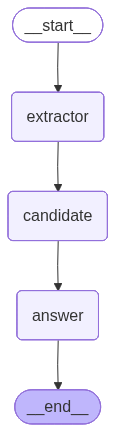

LangGraph 구조:
+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
+-----------+  
| extractor |  
+-----------+  
      *        
      *        
      *        
+-----------+  
| candidate |  
+-----------+  
      *        
      *        
      *        
  +--------+   
  | answer |   
  +--------+   
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   

최종 응답:
### 사용자 증상 및 운동 추천 가이드

**1. 증상 설명**
- **목표**: 체력 향상과 체중 관리를 통한 건강 개선을 목표로 하고 있습니다.
- **기대 효과**: 효과적인 운동 루틴을 통해 에너지 수준을 높이고, 건강한 체중 유지 또는 감량을 이루고자 합니다.

**2. 추천 운동 목록**
1. **유산소 운동**
2. **고강도 인터벌 트레이닝 (HIIT)**
3. **스쿼트**
4. **플랭크**
5. **걷기 인터벌**

**3. 운동 특징**
1. **유산소 운동**:
   - 장시간 지속 가능한 운동으로, 심폐 기능 향상 및 체지방 감소에 효과적입니다.
2. **고강도 인터벌 트레이닝 (HIIT)**:
   - 짧은 시간 동안 고강도 운동 후 휴식을 반복하는 방식으로, 칼로리 소모가 빠르고 효율적입니다.
3. **스쿼트**:
   - 하체 근력 강화에 탁월하며, 전체적인 신체 균형과 안정성 향상에 기여합니다.
4. **플랭크**:
   - 코어 근육 강화에 매우 효과적이며, 전신 근육 균형을 개선합니다.
5. **걷기 인터벌**:
   - 일상

In [6]:
from langchain_community.llms import Ollama
from langchain_core.prompts import PromptTemplate
from langgraph.graph import StateGraph, END
from typing import TypedDict

# 1. 상태 정의
class AgentState(TypedDict):

    query: str                    # 사용자 질문
    symptoms: str                 # 추출된 증상
    exercise_candidates: str      # 추천 운동 후보
    result: str                   # 최종 응답

# 2. LLM 초기화
llm = Ollama(
    model="exaone3.5:2.4b"
)

# 3. 추출 에이전트
# 사용자 질문에서 증상 추출
extractor_prompt = PromptTemplate.from_template("""
사용자의 질문에서 운동과 관련된 증상을 추출하세요.

결과는 쉼표로 구분된 문자열로 출력하세요.

질문:
{query}
""")


def extractor_agent(state: AgentState):

    chain = extractor_prompt | llm

    symptoms = chain.invoke({
        "query": state["query"]
    })

    return {
        **state,
        "symptoms": symptoms.strip()
    }

# 4. 후보 에이전트
# 증상을 해결할 운동 리스트 추출
candidate_prompt = PromptTemplate.from_template("""
다음 증상을 해결하는데 도움이 되는 운동 5개를 추천하세요.

증상:
{symptoms}

운동 이름만 쉼표로 출력하세요.
""")


def candidate_agent(state: AgentState):

    chain = candidate_prompt | llm

    exercises = chain.invoke({
        "symptoms": state["symptoms"]
    })

    return {
        **state,
        "exercise_candidates": exercises.strip()
    }

# 5. 답변 생성 에이전트
# 개조식 최종 출력 생성
answer_prompt = PromptTemplate.from_template("""
사용자의 증상은 다음과 같습니다:

{symptoms}

추천 운동 목록:

{exercise_candidates}

위 내용을 바탕으로 사용자에게 알기 쉽게 설명해주세요.

반드시 아래 형식으로 작성하세요.

1. 증상 설명
2. 추천 운동
3. 운동 특징
4. 추천 이유
5. 추가 조언

각 운동은 번호를 붙여 설명하세요.

답변은 반드시 개조식 한국어로 작성하세요.
""")


def answer_agent(state: AgentState):

    chain = answer_prompt | llm

    answer = chain.invoke({

        "symptoms": state["symptoms"],

        "exercise_candidates": state["exercise_candidates"]
    })

    return {
        **state,
        "result": answer.strip()
    }

# 6. LangGraph 정의
graph = StateGraph(AgentState)

graph.add_node("extractor", extractor_agent)

graph.add_node("candidate", candidate_agent)

graph.add_node("answer", answer_agent)

# 시작 노드
graph.set_entry_point("extractor")

# 연결
graph.add_edge("extractor", "candidate")

graph.add_edge("candidate", "answer")

graph.add_edge("answer", END)

# 그래프 컴파일
app = graph.compile()


# 7. LangGraph 구조 출력
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

print("LangGraph 구조:")
app.get_graph().print_ascii()

# 8. 실행
query = "체력이 안좋고 살이 계속 찌는데 어떤 운동을 할까?"

result = app.invoke({
    "query": query
})

print("\n최종 응답:")
print(result["result"])